In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g7_market_synopsis_embeddings.csv"
)

print(model_df.shape)
model_df.head()

(2255, 426)


,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,production_budget,...,g7_market_synopsis_emb_374,g7_market_synopsis_emb_375,g7_market_synopsis_emb_376,g7_market_synopsis_emb_377,g7_market_synopsis_emb_378,g7_market_synopsis_emb_379,g7_market_synopsis_emb_380,g7_market_synopsis_emb_381,g7_market_synopsis_emb_382,g7_market_synopsis_emb_383
0,tt0120667,Fantastic Four,2005.0,56061504.0,3602.0,2005-07-08,Wide,Wide,20th Century Fox,87500000.0,...,-0.010731,-0.014368,-0.078022,0.003610,-0.058226,-0.032532,-0.038527,-0.072058,-0.074371,-0.039796
1,tt0121164,Corpse Bride,2005.0,19145480.0,3204.0,2005-09-16,Expands Wide,Expands Wide,Warner Bros.,40000000.0,...,0.076011,-0.122633,0.034158,0.081395,0.050829,0.028579,0.025510,0.038926,0.038335,-0.021903
2,tt0121766,Star Wars: Episode III - Revenge of the Sith,2005.0,108435841.0,3661.0,2005-05-19,Wide,Wide,20th Century Fox,115000000.0,...,-0.062428,0.013874,-0.101026,0.095624,0.053449,0.027899,0.081364,-0.019306,0.028493,-0.003193
3,tt0167190,Hellboy,2004.0,23172440.0,3028.0,2004-04-02,Wide,Wide,Sony Pictures,60000000.0,...,0.031220,-0.089104,0.004114,-0.008470,0.000972,0.000932,0.062636,-0.084109,-0.054190,-0.075343
4,tt0200465,The Bank Job,2008.0,5935256.0,1603.0,2008-03-07,Wide,Wide,Lionsgate,20000000.0,...,0.020103,-0.030943,-0.050717,0.072772,-0.006696,0.006582,-0.032968,-0.043960,0.058457,-0.035927


In [3]:
g7_features = [col for col in model_df.columns if col.startswith("g7_")]

In [4]:
target = "log_opening_weekend_gross"

num_group_features = [

]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g7_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

cat_group_feature = [

]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    "franchise",
 ] + people_features + cat_group_feature

In [5]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [6]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 403)
(1493,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
y_test_dollars = np.expm1(y_test)

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [11]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'Ridge Baseline',
 'r2_log': 0.33653683099305387,
 'mae_log': 1.2559471677524938,
 'mae_dollars': 11271540.568062266}

In [12]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'XGBoost Baseline',
 'r2_log': 0.557482759005042,
 'mae_log': 0.9969849207908221,
 'mae_dollars': 7443882.621790245}

In [13]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.336537,1.255947,1.127154e+07
1,XGBoost Baseline,0.557483,0.996985,7.443883e+06


In [14]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [15]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


In [16]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

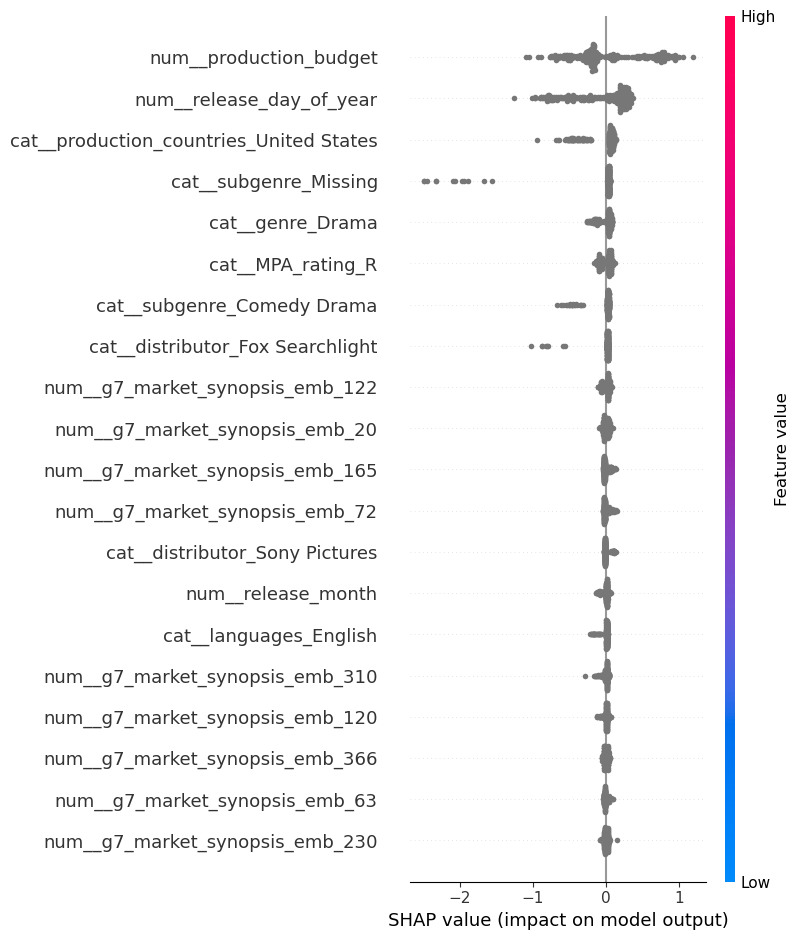

In [17]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

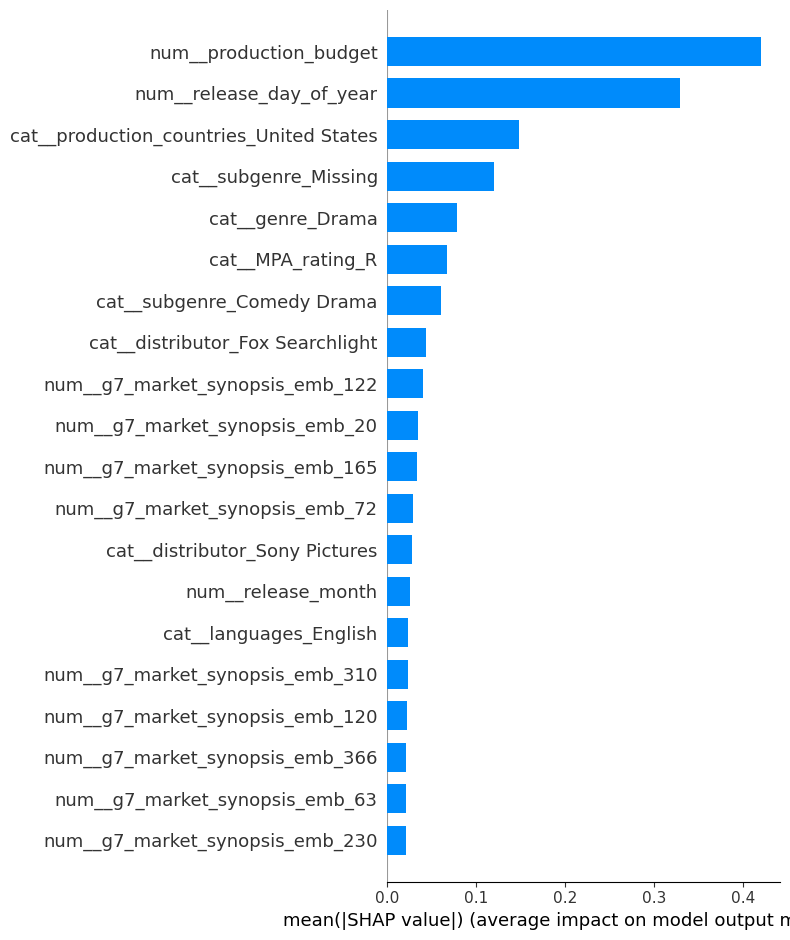

In [18]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [19]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g7_market_synopsis_emb_0,g7_market_synopsis_emb_1,g7_market_synopsis_emb_2,g7_market_synopsis_emb_3,g7_market_synopsis_emb_4,g7_market_synopsis_emb_5,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
2084,182000000.0,128.0,5,144,-0.014757,-0.026634,0.015806,0.029831,-0.075846,0.045513,...,nm0005363,nm0041864,nm0000226,nm4565815,nm4305463,18.331860,16.235041,91500929.0,11240575.0,80260354.0
1289,100000000.0,180.0,7,202,-0.035258,0.059951,-0.084583,0.091215,-0.014812,0.016422,...,nm0634240,nm0634240,nm0614165,nm1289434,nm0000354,18.227768,16.420031,82455420.0,13524731.0,68930689.0
863,175000000.0,89.0,5,149,-0.012080,0.158339,-0.049407,0.007541,-0.029371,0.008568,...,nm0230032,nm0677037,nm0000799,nm2973712,nm0001652,18.036617,16.641033,68108790.0,16869760.0,51239030.0
1034,185000000.0,93.0,6,174,0.032620,0.036313,-0.003885,0.013518,0.013036,-0.007274,...,nm0028764,nm0028764,nm0531808,nm0175262,nm0000668,18.010056,17.014555,66323594.0,24509096.0,41814498.0
1158,160000000.0,147.0,7,197,-0.066197,0.096602,-0.010888,-0.088031,0.100750,0.035611,...,nm0634240,nm0634240,nm0000138,nm0330687,nm0680983,17.955232,16.860001,62785337.0,20999320.0,41786017.0
876,25000000.0,130.0,8,222,-0.047061,-0.040216,0.076424,-0.046729,-0.052146,0.082616,...,nm1682573,nm8631159,nm0515116,nm1682573,nm2809577,17.727867,16.338804,50016652.0,12469599.0,37547053.0
1883,108000000.0,130.0,10,275,0.037054,0.049276,0.020642,-0.023111,0.077963,-0.030936,...,nm0000631,nm1206844,nm0000354,nm1567113,nm1325419,17.810193,16.709076,54308575.0,18057576.0,36250999.0
90,105000000.0,115.0,7,198,-0.066801,-0.094613,0.058400,-0.090771,0.033935,-0.048549,...,nm0001639,nm0899113,nm0000226,nm0005256,nm0339304,17.770208,16.835714,52179887.0,20495468.0,31684419.0
961,30000000.0,111.0,8,226,-0.042555,0.001856,-0.055431,-0.048876,0.056000,0.022271,...,nm0088955,nm0088955,nm1663205,nm3107870,nm2271261,17.435959,15.695852,37354308.0,6555743.5,30798564.5
27,75000000.0,90.0,10,275,-0.108885,0.057119,-0.050850,-0.013166,-0.057397,0.071170,...,nm0074426,nm5022110,nm0000226,nm0000134,nm0000250,17.678440,16.642004,47604606.0,16886144.0,30718462.0


In [21]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g7_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g7_xgb_test_errors.csv",
    index=False
)